# EDA — Fashion Product Images

Before building anything, three questions worth answering up front:

1. **How balanced is the target?** It drives whether accuracy alone is a fair metric.
2. **Do the structured attributes actually carry signal about the target?** This is the whole premise of the multi-modal model — if `gender`, `baseColour`, `season`, `usage` are independent of `subCategory`, there's no reason to expect the attribute branch to help, and I'd want to know that before training, not after.
3. **What image size is the photo actually worth resizing to?** The source images aren't square, so the choice isn't obvious.

Everything here reads from the cached arrays written by `src/data.py` (run `python -m src.run_all` once, or just `python -c "from src.data import prepare_dataset; prepare_dataset()"`).

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.data import IMG_SIZE, PROCESSED_DIR, ATTRIBUTE_COLUMNS, load_label_maps

maps = load_label_maps()
class_names = maps["target_classes"]
attribute_classes = maps["attribute_classes"]

images = np.load(PROCESSED_DIR / f"images_{IMG_SIZE}.npy")
labels = np.load(PROCESSED_DIR / f"{maps['target_column'].lower()}.npy")
attrs = {col: np.load(PROCESSED_DIR / f"{col.lower()}.npy") for col in ATTRIBUTE_COLUMNS}

print(f"{len(images):,} products | target = {maps['target_column']} ({len(class_names)} classes)")
print(f"attributes: {', '.join(f'{c} ({len(attribute_classes[c])})' for c in ATTRIBUTE_COLUMNS)}")

C:\Users\vitor\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.sparse import issparse


43,704 products | target = subCategory (27 classes)
attributes: gender (5), baseColour (46), season (4), usage (7)


## 1. Target balance

The raw dataset has 45 `subCategory` values, but a long tail of them have only a handful of examples. `src/data.py` drops anything under 100 samples (18 classes, 368 rows — 0.8% of the data), leaving 27 classes that each have enough examples to land in every split. Even within those 27, the imbalance is steep.

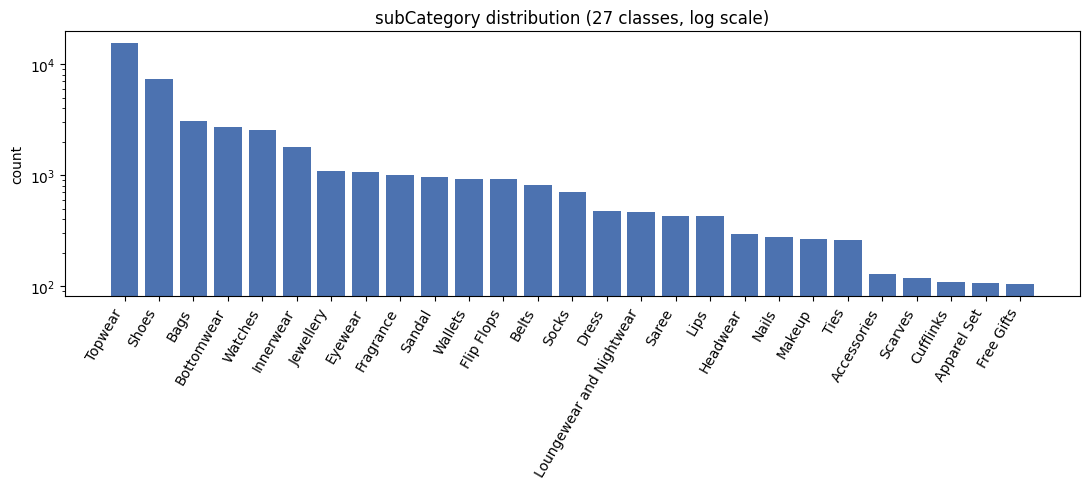

Largest class: Topwear (15,383, 35.2% of the data)
Smallest kept class: Free Gifts (104)
Imbalance ratio (largest / smallest): 148x


In [2]:
counts = np.array([(labels == i).sum() for i in range(len(class_names))])
order = np.argsort(counts)[::-1]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([class_names[i] for i in order], counts[order], color="#4C72B0")
ax.set_ylabel("count")
ax.set_title("subCategory distribution (27 classes, log scale)")
ax.set_yscale("log")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

top = order[0]
print(f"Largest class: {class_names[top]} ({counts[top]:,}, {counts[top]/counts.sum():.1%} of the data)")
print(f"Smallest kept class: {class_names[order[-1]]} ({counts[order[-1]]})")
print(f"Imbalance ratio (largest / smallest): {counts.max() / counts.min():.0f}x")

Topwear alone is roughly a third of the catalog, and the largest class outnumbers the smallest by ~150x. Two consequences I carry into the modeling:

- **Accuracy will be misleadingly high** — a model that only ever guessed the top few classes would already score well. So the headline metric in the case study is **macro-F1** (every class weighted equally), with accuracy reported alongside but not leaned on.
- **The loss is class-weighted** (inverse frequency) so the rare classes aren't ignored during training.

## 2. Do the attributes carry signal about subCategory?

This is the question that justifies building a multi-modal model at all. If an attribute is statistically independent of the target, feeding it to the model is just noise.

I use **Cramér's V** — a 0-to-1 measure of association between two categorical variables (0 = independent, 1 = one perfectly determines the other). It's a more honest answer than eyeballing a crosstab, especially with 27 target classes.

In [3]:
def cramers_v(x, y):
    """Bias-corrected Cramér's V between two integer-encoded categorical arrays."""
    nx, ny = x.max() + 1, y.max() + 1
    table = np.zeros((nx, ny))
    np.add.at(table, (x, y), 1)
    n = table.sum()
    row, col = table.sum(1, keepdims=True), table.sum(0, keepdims=True)
    expected = row @ col / n
    chi2 = ((table - expected) ** 2 / expected).sum()
    phi2 = chi2 / n
    # bias correction (Bergsma 2013)
    phi2_corr = max(0, phi2 - (nx - 1) * (ny - 1) / (n - 1))
    r_corr = nx - (nx - 1) ** 2 / (n - 1)
    k_corr = ny - (ny - 1) ** 2 / (n - 1)
    return np.sqrt(phi2_corr / min(r_corr - 1, k_corr - 1))

associations = {col: cramers_v(attrs[col], labels) for col in ATTRIBUTE_COLUMNS}
for col, v in sorted(associations.items(), key=lambda kv: -kv[1]):
    print(f"{col:>12}  Cramér's V = {v:.3f}")

      season  Cramér's V = 0.641
      gender  Cramér's V = 0.306
       usage  Cramér's V = 0.277
  baseColour  Cramér's V = 0.221


All four attributes are *associated* with subcategory — none is pure noise — but the strengths differ, and even the strongest is well short of 1.0. That's the early warning the case study later confirms: the attributes carry *some* signal, but the photo carries most of it. An association of, say, 0.3–0.5 means an attribute narrows the candidates but rarely pins down the subcategory on its own.

The crosstab below makes one of these concrete: `gender` shifts the category mix, but most categories appear across multiple genders.

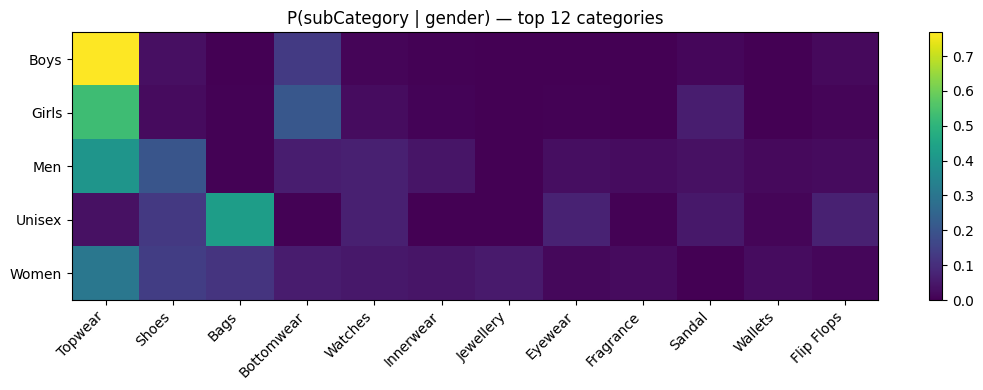

In [4]:
gender_names = attribute_classes["gender"]
g = attrs["gender"]
# P(subCategory | gender), restricted to the most common categories for readability
top_classes = order[:12]
crosstab = np.zeros((len(gender_names), len(top_classes)))
for gi in range(len(gender_names)):
    mask = g == gi
    total = mask.sum()
    if total:
        for ci, c in enumerate(top_classes):
            crosstab[gi, ci] = (labels[mask] == c).mean()

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(crosstab, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(top_classes)))
ax.set_xticklabels([class_names[c] for c in top_classes], rotation=45, ha="right")
ax.set_yticks(range(len(gender_names)))
ax.set_yticklabels(gender_names)
ax.set_title("P(subCategory | gender) — top 12 categories")
fig.colorbar(im)
plt.tight_layout()
plt.show()

## 3. Image size

The source photos are roughly 60×80 (portrait, ~3:4), not square. The model resizes to **80×80** — square keeps the tensor shape simple, and 80 is close to the original height so it isn't throwing away much detail. A smaller square like 64×64 would distort the aspect ratio more for no real gain. The samples below are what the model actually sees after the resize.

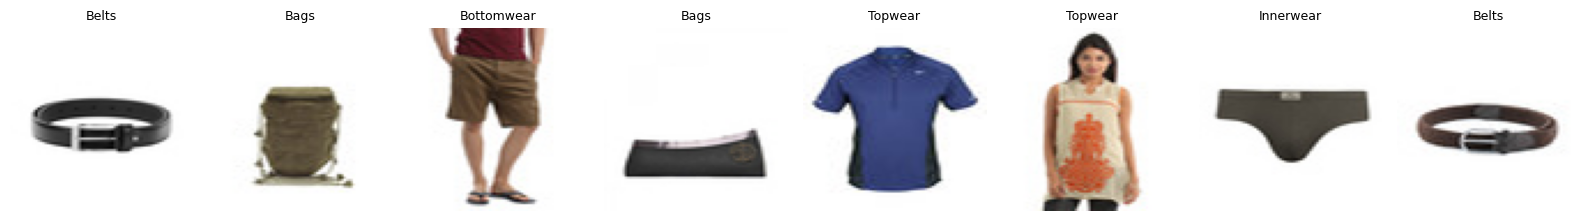

In [5]:
rng = np.random.default_rng(7)
picks = rng.choice(len(images), size=8, replace=False)
fig, axes = plt.subplots(1, 8, figsize=(16, 2.5))
for ax, idx in zip(axes, picks):
    ax.imshow(images[idx])
    ax.set_title(class_names[labels[idx]], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

**Takeaways carried into the modeling:**
- 27-class, heavily imbalanced target → macro-F1 as the headline metric, class-weighted loss.
- The attributes are associated with the target but weakly — enough to be worth testing as a second modality, not enough to assume they'll help. The case study (`02_case_study.ipynb`) settles that empirically.
- 80×80 RGB is a deliberate, justified resize, not a default.